In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

#### Data Wrangling

In [70]:
df = pd.read_csv("./dataset/PJME_hourly.csv").set_index("Datetime")
df.index = pd.to_datetime(df.index)
df = df.sort_index()
df.head()

,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


In [71]:
df.head()

,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


#### Exploratory Data Analysis

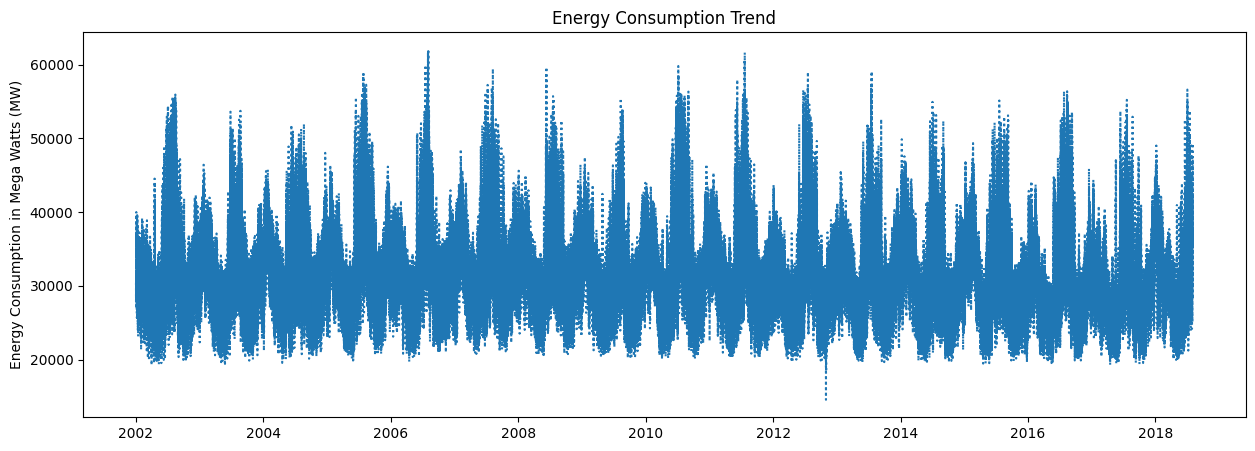

In [72]:
fig, ax = plt.subplots(figsize=(15,5))
ax.plot(df, linestyle="dotted")
plt.ylabel("Energy Consumption in Mega Watts (MW)")
plt.title("Energy Consumption Trend");

#### Train / Test Split

In [73]:
df.index<"01-01-2015" # This gives an mask array of true and false

array([ True,  True,  True, ..., False, False, False], shape=(145366,))

In [74]:
df.loc[df.index<"01-01-2015"].tail()

,PJME_MW
Datetime,
2014-12-31 19:00:00,38906.0
2014-12-31 20:00:00,37772.0
2014-12-31 21:00:00,36602.0
2014-12-31 22:00:00,35326.0
2014-12-31 23:00:00,34003.0


In [75]:
train = df.loc[df.index<"01-01-2015"]
test = df.loc[df.index>="01-01-2015"]

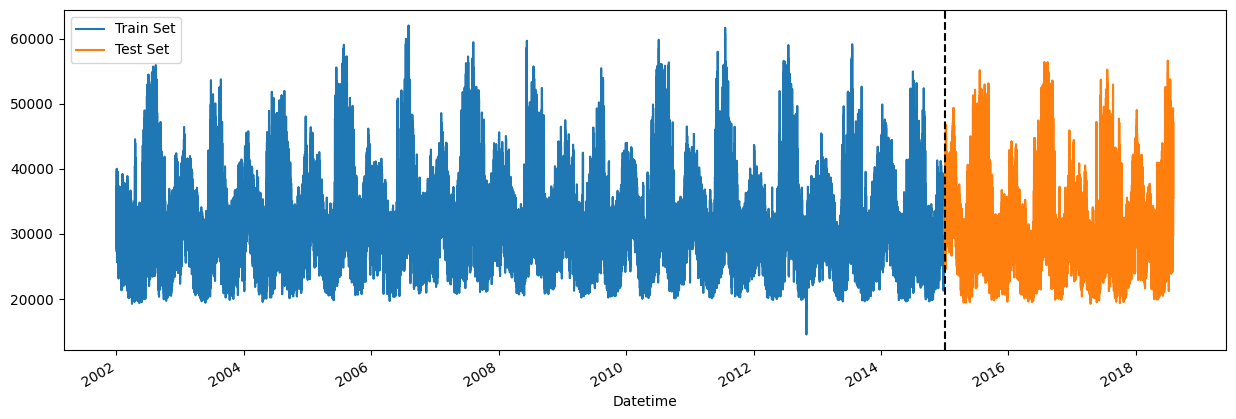

In [76]:
fig, ax = plt.subplots(figsize=(15,5))
train.plot(ax=ax)
test.plot(ax=ax)
ax.axvline("2015-01-01", color="black", linestyle="--")
ax.legend(["Train Set", "Test Set"])
plt.show()

    Plotting 1 week of data

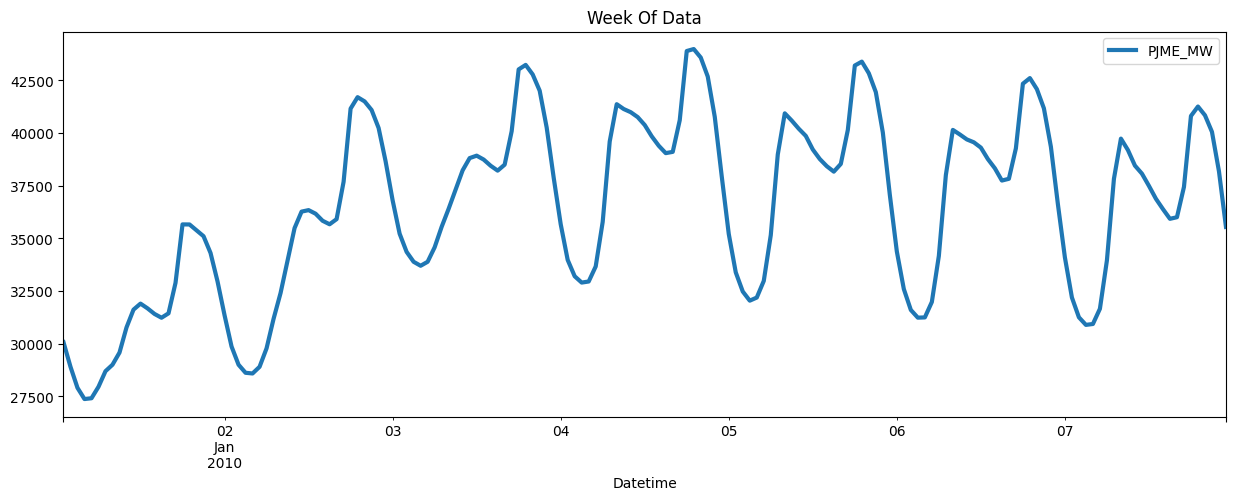

In [79]:
df.loc[(df.index > '01-01-2010') & (df.index < '01-08-2010')] \
    .plot(figsize=(15, 5), title='Week Of Data', linewidth="3")
plt.show()

#### Feature Creation